In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, label
from scipy.spatial.distance import pdist, squareform

In [2]:
index = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index.append(np.array(numbers, dtype=int))

index = np.array(index)

latency = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency.append(np.array(numbers, dtype=float))
        
latency = np.array(latency)

rli = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_rli.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        rli.append(np.array(numbers, dtype=float))
        
rli = np.array(rli)

In [3]:
index_Q = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_03_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index_Q.append(np.array(numbers, dtype=int))

index_Q = np.array(index_Q)

latency_Q = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_03_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency_Q.append(np.array(numbers, dtype=float))
        
latency_Q = np.array(latency_Q)

rli_Q = []

with open('C:/Users/txu245/Desktop/26-03-03/04_01_03_rli.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        rli_Q.append(np.array(numbers, dtype=float))
        
rli_Q = np.array(rli_Q)

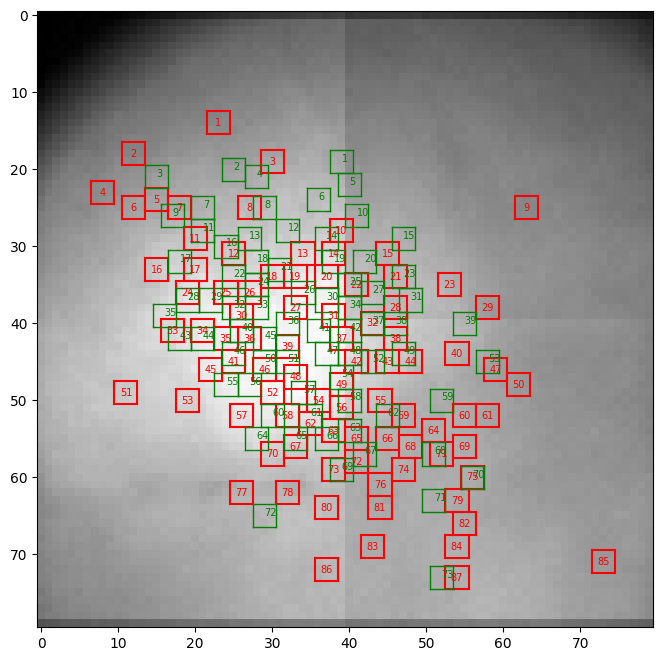

In [4]:
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(rli, cmap='gray')

for i, coor in enumerate(index):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='red', linewidth=1.5)
    ax.plot([bottom, bottom], [left, right], color='red', linewidth=1.5)
    ax.plot([top, bottom], [left, left], color='red', linewidth=1.5)
    ax.plot([top, bottom], [right, right], color='red', linewidth=1.5)
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='red')

for i, coor in enumerate(index_Q):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='green', linewidth=1)
    ax.plot([bottom, bottom], [left, right], color='green', linewidth=1)
    ax.plot([top, bottom], [left, left], color='green', linewidth=1)
    ax.plot([top, bottom], [right, right], color='green', linewidth=1)
    ax.annotate(str(i+1), xy=(r, c), fontsize=7, color='green')
    
plt.show()

Neuron 33 and Neuron 19 are correlated with a positive slope, and the P-Value is: 0.011269 , distance is: 104.78549517943787 um.
Neuron 33 and Neuron 47 are correlated with a positive slope, and the P-Value is: 0.002505 , distance is: 253.7794317906792 um.
Neuron 33 and Neuron 71 are correlated with a positive slope, and the P-Value is: 0.003118 , distance is: 230.90257685872626 um.
Neuron 33 and Neuron 80 are correlated with a positive slope, and the P-Value is: 0.033068 , distance is: 182.87700784953805 um.
Neuron 33 and Neuron 81 are correlated with a positive slope, and the P-Value is: 0.049947 , distance is: 212.8097742116184 um.
Neuron 33 and Neuron 82 are correlated with a positive slope, and the P-Value is: 0.026319 , distance is: 272.9175699730598 um.
Neuron 33 and Neuron 83 are correlated with a positive slope, and the P-Value is: 0.005433 , distance is: 229.2596780945136 um.


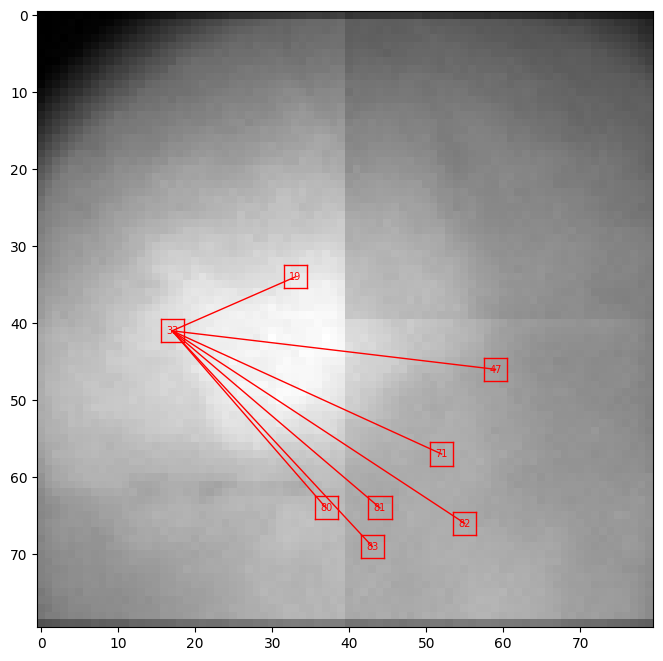

In [9]:
# Slice without Quinine.
neuro_label = 33
count = 0

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(rli, cmap='gray')
top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color='red', linewidth=1)
ax.plot([bottom, bottom], [left, right], color='red', linewidth=1)
ax.plot([top, bottom], [left, left], color='red', linewidth=1)
ax.plot([top, bottom], [right, right], color='red', linewidth=1)
ax.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='red')

Pvalue = []
Distance = []

for i in range(len(index)):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            Pvalue.append(pValue)
            Distance.append(dist)
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color='red', linewidth=1)
            ax.plot([bottom, bottom], [left, right], color='red', linewidth=1)
            ax.plot([top, bottom], [left, left], color='red', linewidth=1)
            ax.plot([top, bottom], [right, right], color='red', linewidth=1)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='red')

plt.show()

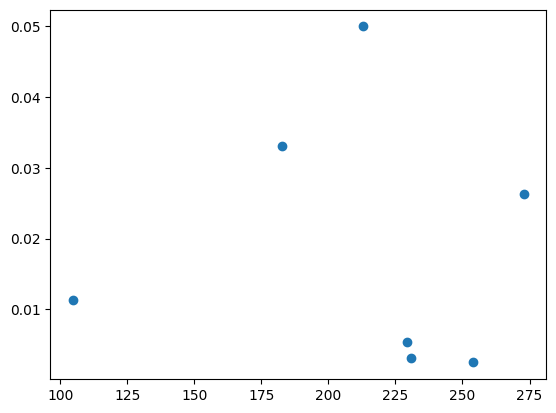

In [10]:
plt.scatter(Distance, Pvalue)
plt.show()

Neuron 43 and Neuron 58 are correlated with a positive slope, and the P-Value is: 0.007241 , distance is: 140.4563989286355 um.


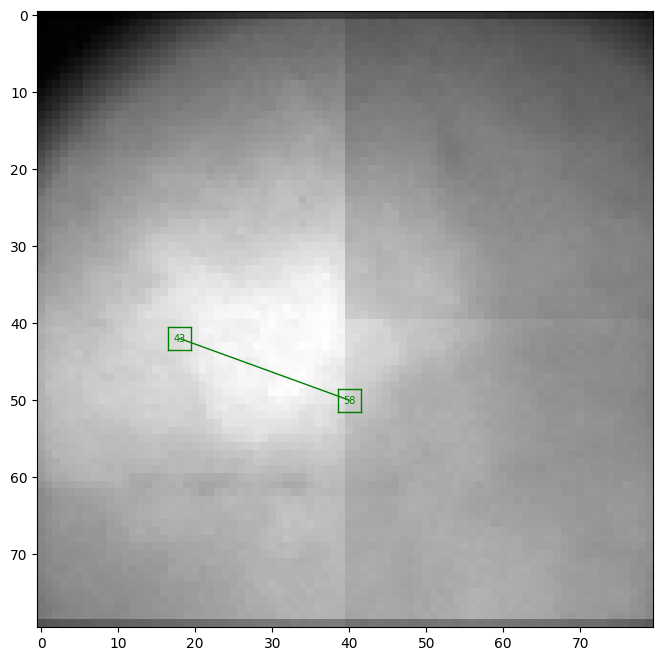

In [11]:
# Slice with Quinine.
neuro_label = 43
count = 0

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(rli_Q, cmap='gray')
top = index_Q[neuro_label-1][1] - 1.5
bottom = index_Q[neuro_label-1][1] + 1.5
left = index_Q[neuro_label-1][0] - 1.5
right = index_Q[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color='green', linewidth=1)
ax.plot([bottom, bottom], [left, right], color='green', linewidth=1)
ax.plot([top, bottom], [left, left], color='green', linewidth=1)
ax.plot([top, bottom], [right, right], color='green', linewidth=1)
ax.annotate(str(neuro_label), xy=(index_Q[neuro_label-1][1], index_Q[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='green')

Pvalue = []
Distance = []

for i in range(len(index_Q)):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index_Q[i][0] - index_Q[neuro_label-1][0])**2 + (index_Q[i][1] - index_Q[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            Pvalue.append(pValue)
            Distance.append(dist)
            loc_1 = index_Q[i]
            loc_2 = index_Q[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='green', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color='green', linewidth=1)
            ax.plot([bottom, bottom], [left, right], color='green', linewidth=1)
            ax.plot([top, bottom], [left, left], color='green', linewidth=1)
            ax.plot([top, bottom], [right, right], color='green', linewidth=1)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='green')

plt.show()

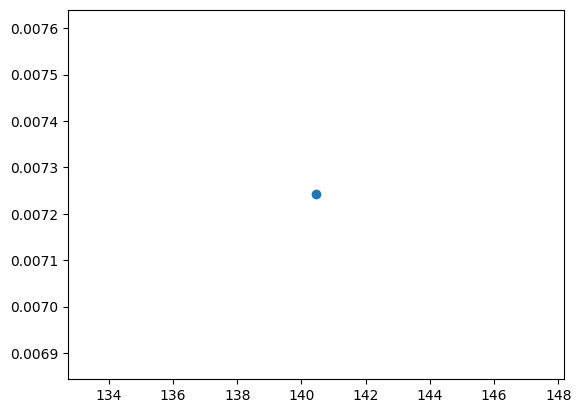

In [12]:
plt.scatter(Distance, Pvalue)
plt.show()

In [ ]:
num = len(index)
trial = latency.shape[1]
count = 0
PValue = []
Distance = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue.append(pValue)
            Distance.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue = np.array(PValue)
Distance = np.array(Distance)

In [ ]:
num = len(index_Q)
trial = latency_Q.shape[1]
count = 0
PValue_Q = []
Distance_Q = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index_Q[i][0] - index_Q[j][0])**2 + (index_Q[i][1] - index_Q[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue_Q.append(pValue)
            Distance_Q.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue_Q = np.array(PValue_Q)
Distance_Q = np.array(Distance_Q)